In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error
from pickle import dump
from pathlib import Path

In [31]:
df = pd.read_csv("../data/diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [33]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [34]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [35]:
print("Cut:\n", df['cut'].value_counts())
print("\nColor:\n", df['color'].value_counts())
print("\nClarity:\n", df['clarity'].value_counts())

Cut:
 cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

Color:
 color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

Clarity:
 clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


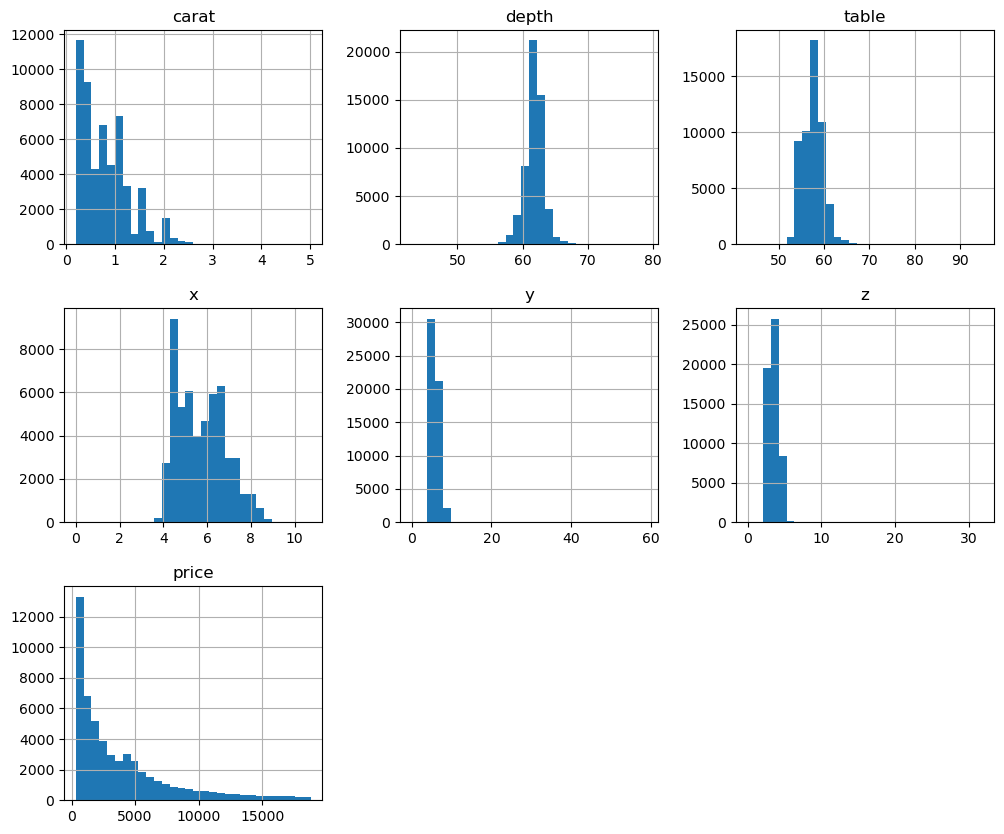

In [36]:
df[['carat', 'depth', 'table', 'x', 'y', 'z', 'price']].hist(bins=30, figsize=(12, 10))
plt.show()

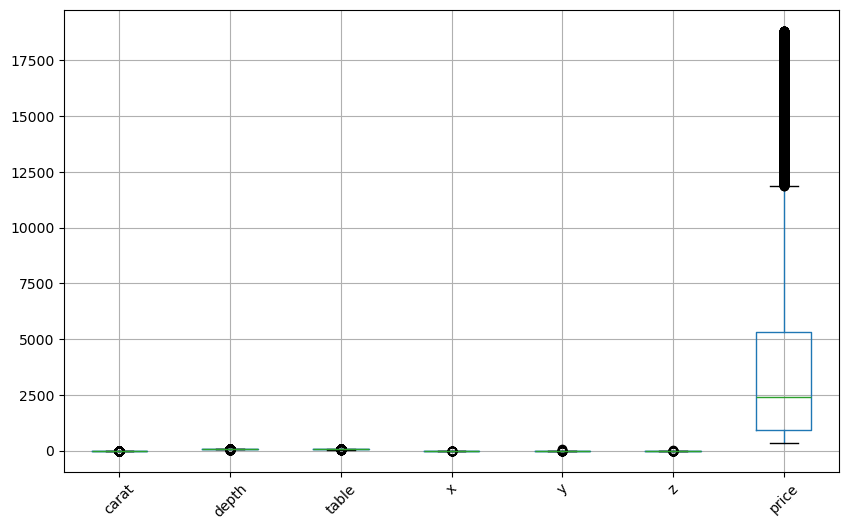

In [37]:
df[['carat', 'depth', 'table', 'x', 'y', 'z', 'price']].boxplot(rot=45, figsize=(10, 6))
plt.show()

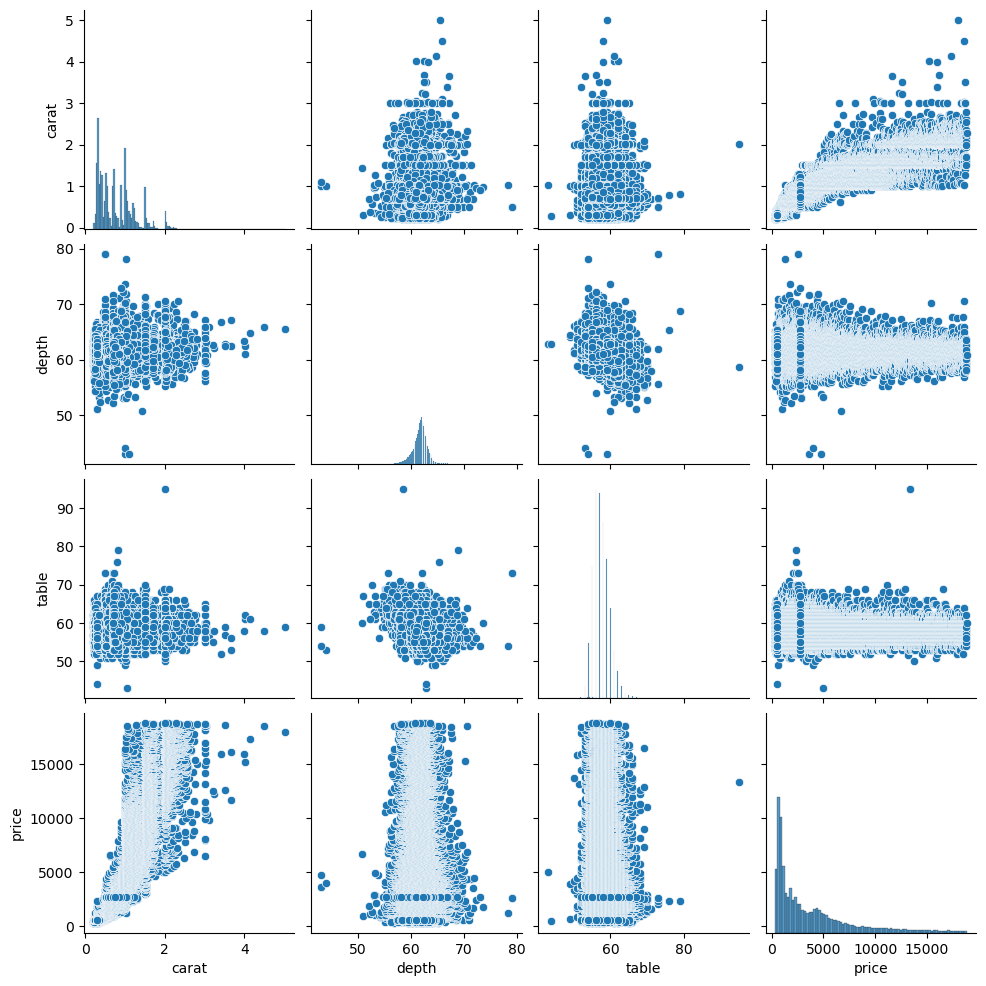

In [38]:
sns.pairplot(df[['carat', 'depth', 'table', 'price']])
plt.show()

In [39]:
X = df.drop('price', axis=1)
y = df['price']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),
    ]
)

In [42]:
categorical_features = ['cut', 'color', 'clarity']
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
    ]
)

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features),
    ]
)

In [44]:
regressor = RandomForestRegressor(random_state=42)

In [45]:
pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ]
)

In [46]:
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5],
}

In [47]:
search_cv = GridSearchCV(pipe, param_grid, cv=3, scoring='r2', n_jobs=-1)
search_cv.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['carat',
                                                                          'depth',
                                                                          'table',
                                                                          'x',
                                                                          'y',
                                                                          'z']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='missing',
                                                                                                        strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['cut',
                                                                          'color',
                                                                          'clarity'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [10, 20, None],
                         'regressor__min_samples_split': [2, 5],
                         'regressor__n_estimators': [100, 200]},
             scoring='r2')

In [48]:
print("Best params:")
print(search_cv.best_params_)

Best params:
{'regressor__max_depth': 20, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}


In [49]:
train_score = search_cv.score(X_train, y_train)
test_score = search_cv.score(X_test, y_test)

In [50]:
y_train_pred = search_cv.predict(X_train)
y_test_pred = search_cv.predict(X_test)

In [51]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

In [52]:
print(f"Train R2: {train_score:.4f}")
print(f"Test R2: {test_score:.4f}")
print(f"Train MAE: {mae_train:.2f}")
print(f"Test MAE: {mae_test:.2f}")

Train R2: 0.9941
Test R2: 0.9746
Train MAE: 152.06
Test MAE: 296.25


In [53]:
Path("../models").mkdir(parents=True, exist_ok=True)

with open("../models/diamonds_pipeline.pkl", "wb") as file:
    dump(search_cv, file)

print("Save ../models/diamonds_pipeline.pkl")

Save ../models/diamonds_pipeline.pkl
